# Aperture Photometry

## 1. Load Data

The `DataBrowser` class allows us to query and filter our synced data. Here we'll explore the available keys and their values to understand what data we have access to.


Let's filter our data to find specific images. We'll search for:
- **Target**: T00528
- **Telescope**: 7DT16  
- **Filter**: r-band
- **Pattern**: Files ending with `*100.fits`


In [1]:
from ezphot.utils import DataBrowser
dbrowser = DataBrowser('scidata')
dbrowser.objname = 'T00528'
dbrowser.telname = '7DT16'
dbrowser.filter = 'r'
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
target_imglist = target_imgset.target_images

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'


Loading Science Images: 100%|██████████| 90/90 [00:00<00:00, 97.42it/s] 


(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'calib_7DT16_T00528_20250905_000408_r_100.fits'}>)

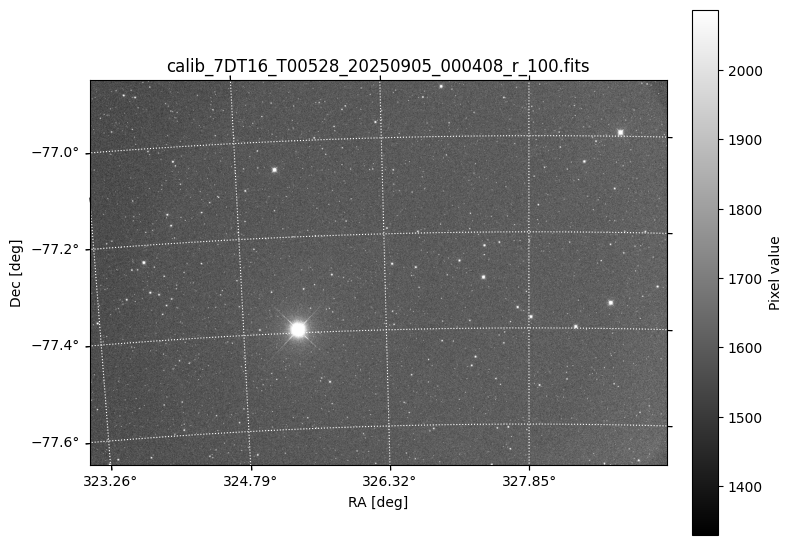

In [2]:
target_img = target_imglist[0]
target_img.show('coord')

## 2. Aperture Photometry 


As you did with source-extractor, you can do photometry easily. 

In [3]:
from ezphot.methods import AperturePhotometry
aperturephot = AperturePhotometry()
aperturephot.help()

Help for AperturePhotometry

Public methods:
- circular_photometry(target_img: Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.referenceimage.ReferenceImage], x_arr: Union[float, list, numpy.ndarray], y_arr: Union[float, list, numpy.ndarray], aperture_diameter_arcsec: Union[float, list] = [5, 7, 10], aperture_diameter_seeing: Union[float, list] = [3.5, 4.5], annulus_width_arcsec: Union[float, list] = None, unit: str = 'pixel', target_bkg: Optional[ezphot.imageobjects.background.Background] = None, target_mask: Union[str, pathlib.Path, numpy.ndarray] = None, target_bkgrms: Optional[ezphot.imageobjects.errormap.Errormap] = None, save: bool = True, verbose: bool = True, visualize: bool = True, save_fig: bool = False, **kwargs)
- elliptical_photometry(target_img: Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.referenceimage.ReferenceImage], x_arr: Union[float, list, numpy.ndarray], y_arr: Union[float, list, numpy.ndarray], sma_arr: Union[f

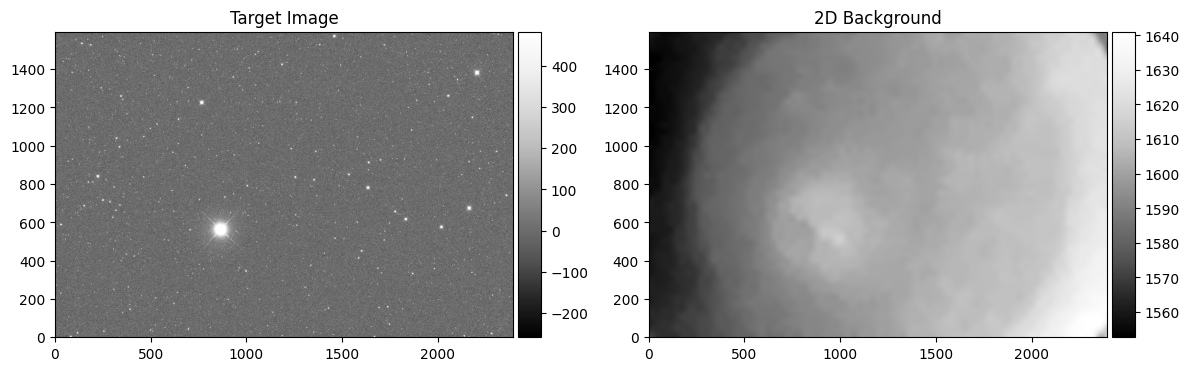

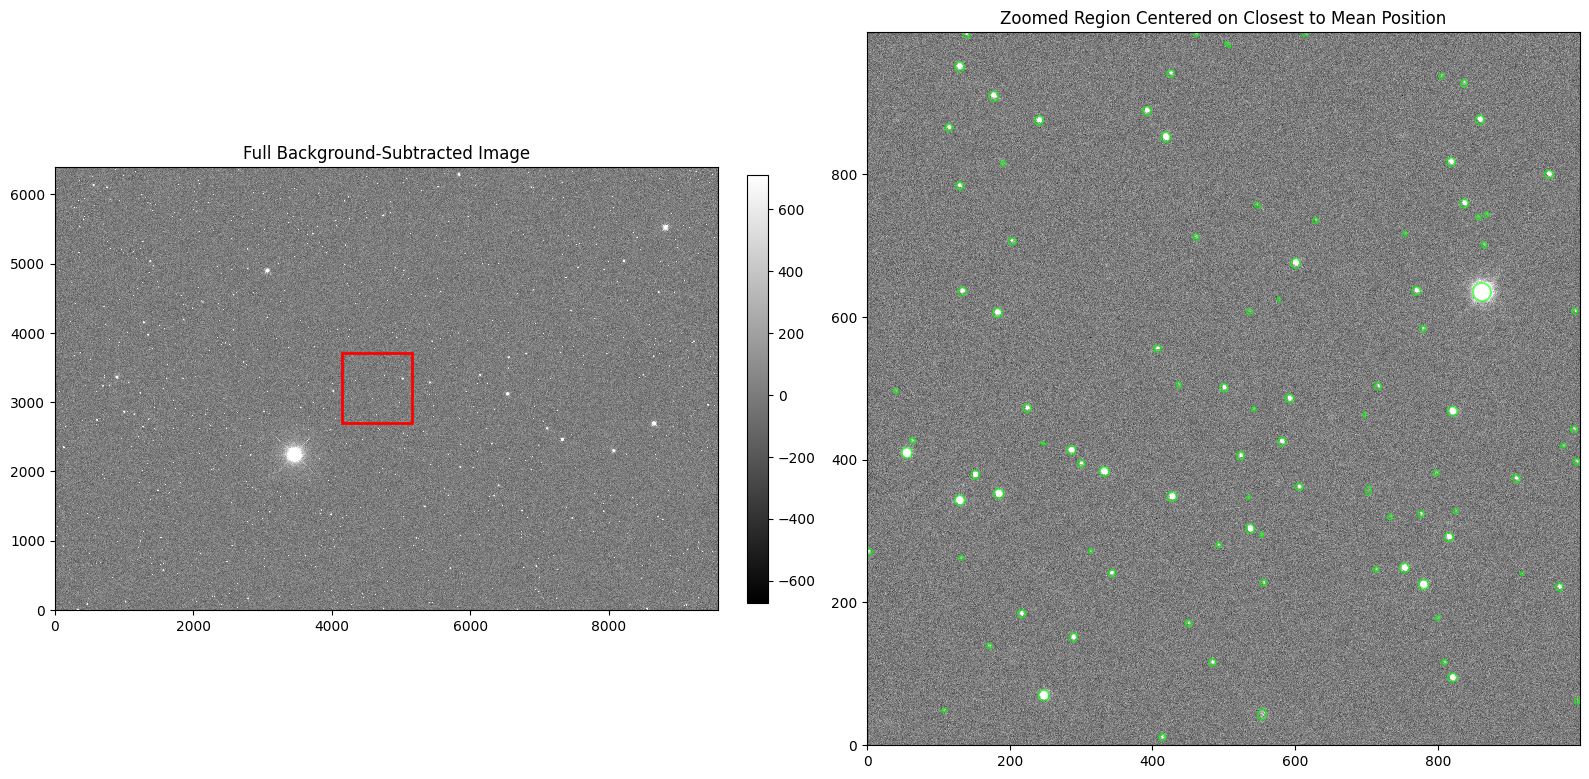

In [ ]:
target_catalog = aperturephot.sex_photometry(
    target_img = target_img,
    target_bkg = None,
    target_bkgrms = None,
    target_mask = None,
    sex_params = None,
    detection_sigma = 3,
    aperture_diameter_arcsec = [5, 7, 10],
    aperture_diameter_seeing = [3.5, 4.5],
    saturation_level = 60000,
    kron_factor = 2.5,
    save = False,
    verbose = False,
    visualize = True,
    save_fig = False,
)

The output will be Catalog instance, which has information about the exposure and catalog data. For more detail, see :ref:`the Catalog class <catalog>`

In [10]:
print(target_catalog.info)

Info ============================================
  path: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits.cat
  target_img: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits
  obsdate: 2025-09-05T00:04:08.000
  filter: r
  exptime: 100.0
  depth: 18.917
  seeing: 2.36567556
  catalog_type: all
  ra: 326.2506400247
  dec: -77.26445076037
  fov_ra: 1.35
  fov_dec: 0.9
  objname: T00528
  observatory: 7DT
  telname: 7DT16
  aperture_diameter_arcsec: None


In [ ]:
print('exptime: ', target_catalog.info.exptime)
print('filter: ', target_catalog.info.filter)
print('telname: ', target_catalog.info.telname)
print('objname: ', target_catalog.info.objname)
print('ra: ', target_catalog.info.ra)
print('dec: ', target_catalog.info.dec)

exptime:  100.0
filter:  r
telname:  7DT16
objname:  T00528
ra:  326.2506400247
dec:  -77.26445076037


In [14]:
target_catalog.data

NUMBER,FLUX_AUTO,FLUXERR_AUTO,FLUX_APER,FLUX_APER_1,FLUX_APER_2,FLUX_APER_3,FLUX_APER_4,FLUXERR_APER,FLUXERR_APER_1,FLUXERR_APER_2,FLUXERR_APER_3,FLUXERR_APER_4,MAG_AUTO,MAGERR_AUTO,MAG_APER,MAG_APER_1,MAG_APER_2,MAG_APER_3,MAG_APER_4,MAGERR_APER,MAGERR_APER_1,MAGERR_APER_2,MAGERR_APER_3,MAGERR_APER_4,FWHM_IMAGE,FWHM_WORLD,X_IMAGE,Y_IMAGE,XWIN_IMAGE,YWIN_IMAGE,X_WORLD,Y_WORLD,ALPHA_J2000,DELTA_J2000,FLAGS,CLASS_STAR,THRESHOLD,A_IMAGE,B_IMAGE,ELONGATION,ELLIPTICITY,KRON_RADIUS,FLUX_RADIUS,THETA_IMAGE,THETA_WORLD,THETA_SKY,THETA_J2000,BACKGROUND,FLUX_MAX,ISOAREA_IMAGE,SKYSIG,SKYVAL,DETECT_THRESH,NPIX_AUTO,NPIX_APER,PIXSIZE_APER,NPIX_APER_1,PIXSIZE_APER_1,NPIX_APER_2,PIXSIZE_APER_2,NPIX_APER_3,PIXSIZE_APER_3,NPIX_APER_4,PIXSIZE_APER_4
,ct,ct,ct,ct,ct,ct,ct,ct,ct,ct,ct,ct,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,pix,deg,pix,pix,pix,pix,deg,deg,deg,deg,,,ct,pix,pix,,,,pix,deg,deg,deg,deg,ct,ct,pix2,,,,,,,,,,,,,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str7,str1,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,3474970.0,4121.366,2614184.0,3123566.0,3389806.0,3274942.0,3417686.0,3280.912,3645.505,3935.1,3786.016,3986.333,-16.3524,0.0013,-16.0433,-16.2366,-16.3254,-16.288,-16.3343,0.0014,0.0013,0.0013,0.0013,0.0013,6.81,0.0009596373,465.399,85.0836,466.1606,86.0496,323.34446643,-77.669369721,323.3444664,-77.6693697,4,0.98,127.2467,3.738,3.275,1.141,0.124,3.5,3.334,72.05,69.59,20.41,20.41,0.683493,74826.42,765,79.7884,0,3,471.1254472737662,76.28541073796102,9.855435131841535,149.51940504640356,13.797609184578148,305.14164295184406,19.71087026368307,209.1933791639988,16.32033341719403,345.80946351599795,20.983285822106605
2,4683292.0,4698.114,3680859.0,4237371.0,4550494.0,4407084.0,4591606.0,3868.563,4208.255,4488.833,4340.829,4541.944,-16.6764,0.0011,-16.4149,-16.5677,-16.6451,-16.6104,-16.6549,0.0011,0.0011,0.0011,0.0011,0.0011,5.26,0.0007412169,9107.2539,75.121,9108.3396,76.0409,329.05032246,-77.706008552,329.0503225,-77.7060086,4,1.0,131.1449,3.594,3.529,1.019,0.018,3.5,3.202,-61.01,-66.17,-23.83,-23.83,4.247592,77110.84,921,79.7884,0,3,488.1077379113834,76.28541073796102,9.855435131841535,149.51940504640356,13.797609184578148,305.14164295184406,19.71087026368307,209.1933791639988,16.32033341719403,345.80946351599795,20.983285822106605
3,89170.51,1388.597,79127.55,86329.8,93204.63,89297.84,94107.69,950.3466,1224.837,1653.531,1405.845,1749.46,-12.3756,0.0169,-12.2458,-12.3404,-12.4236,-12.3771,-12.4341,0.013,0.0154,0.0193,0.0171,0.0202,4.03,0.0005685684,8996.9189,33.0811,8997.8257,34.1069,328.97806299,-77.712246785,328.978063,-77.7122468,0,0.983,131.299,2.036,2.004,1.016,0.015,3.99,2.382,66.81,64.67,25.33,25.33,4.700016,4257.846,91,79.7884,0,3,204.0662364375781,76.28541073796102,9.855435131841535,149.51940504640356,13.797609184578148,305.14164295184406,19.71087026368307,209.1933791639988,16.32033341719403,345.80946351599795,20.983285822106605
4,2756657.0,3645.594,2342736.0,2596341.0,2738630.0,2673359.0,2758030.0,3116.256,3353.08,3599.24,3462.755,3651.51,-16.101,0.0014,-15.9243,-16.0359,-16.0938,-16.0676,-16.1015,0.0014,0.0014,0.0014,0.0014,0.0014,4.47,0.0006300149,8536.9443,23.8746,8537.9367,24.8449,328.67459584,-77.714705528,328.6745958,-77.7147055,6,0.997,128.0749,3.03,2.939,1.031,0.03,3.5,2.622,-62.62,-64.59,-25.41,-25.41,11.41325,72875.21,604,79.7884,0,3,342.71110397436064,76.28541073796102,9.855435131841535,149.51940504640356,13.797609184578148,305.14164295184406,19.71087026368307,209.1933791639988,16.32033341719403,345.80946351599795,20.983285822106605
5,87377.32,1566.148,67211.56,80716.19,88600.88,83654.29,89874.65,911

If you do not input target_bkg and target_bkgrms, this code calculate the background/RMS map as source-extractor does.
 

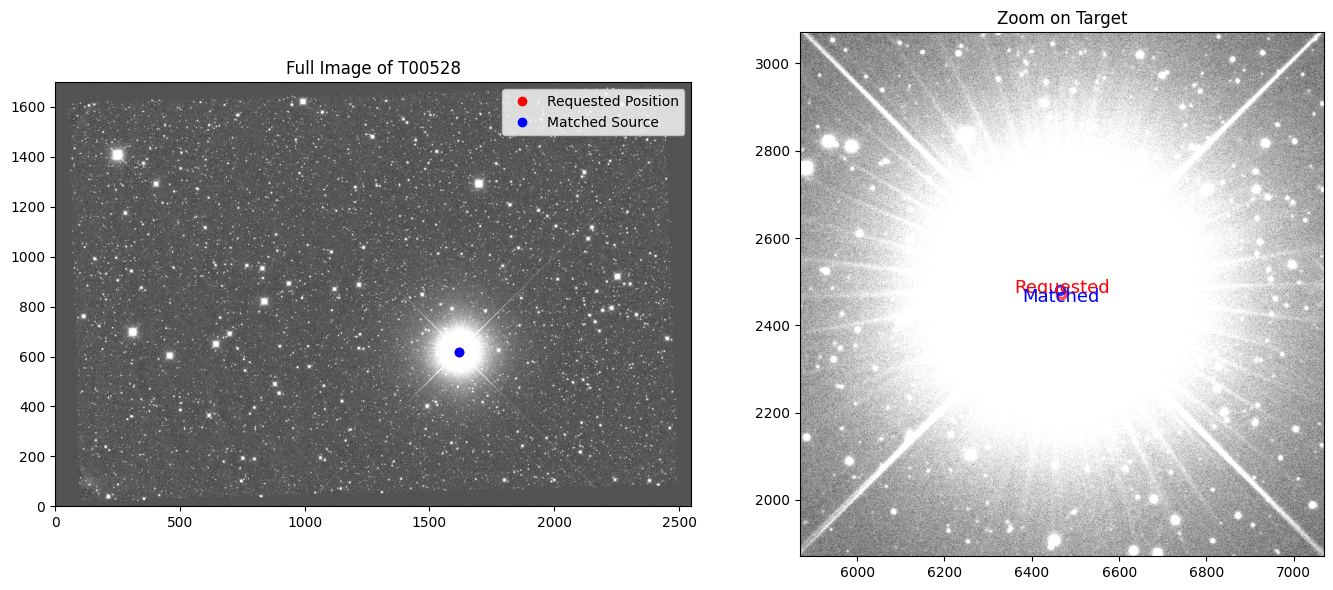

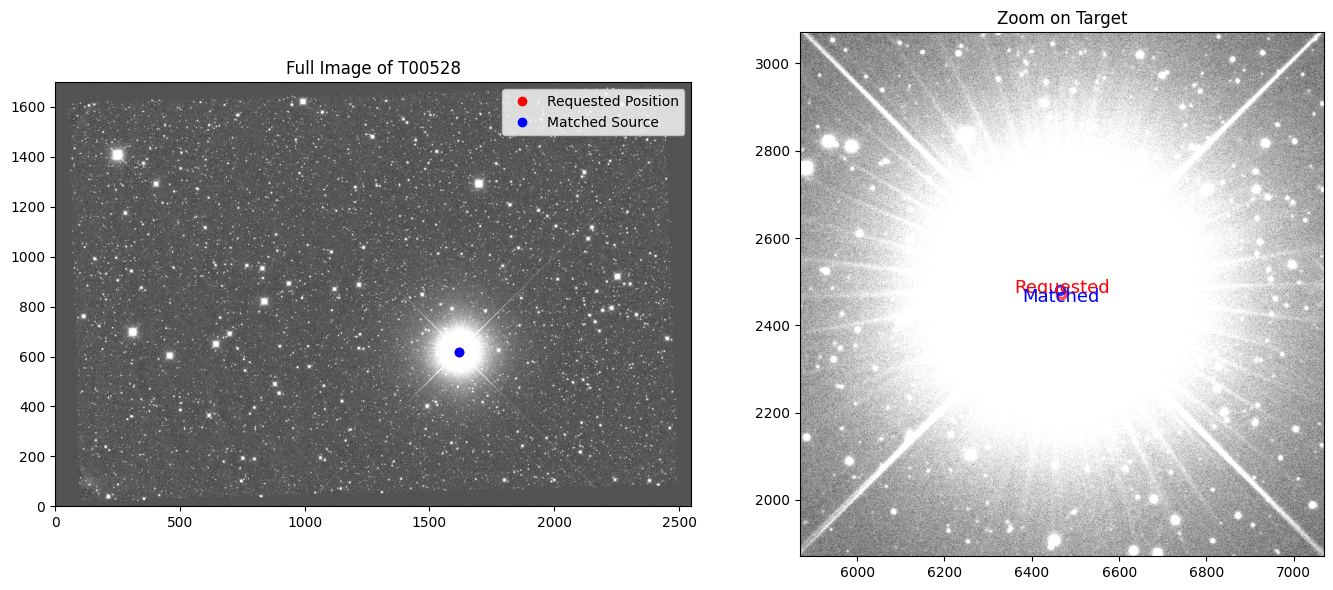

In [6]:
target_catalog.show_source(
    target_ra = 325.37,
    target_dec = -77.393,
    downsample = 4,
    zoom_radius_pixel = 600,
    matching_radius_arcsec = 5,
)

In [8]:
target_srcmask = target_img.calculate_circularmask(
    target_srcmask = None,
    x_position = 325.37,
    y_position = -77.393,
    radius_arcsec = 600,
    unit = 'coord',
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False,
)
target_srcmask = target_img.calculate_sourcemask(
    target_srcmask = target_srcmask,
    sigma = 5,
    mask_radius_factor = 2,
    saturation_level = 50000,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False,
)
target_ivpmask = target_img.calculate_invalidmask(
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False,
)

TypeError: MaskGenerator.mask_sources() got an unexpected keyword argument 'mask_type'

External mask is loaded.


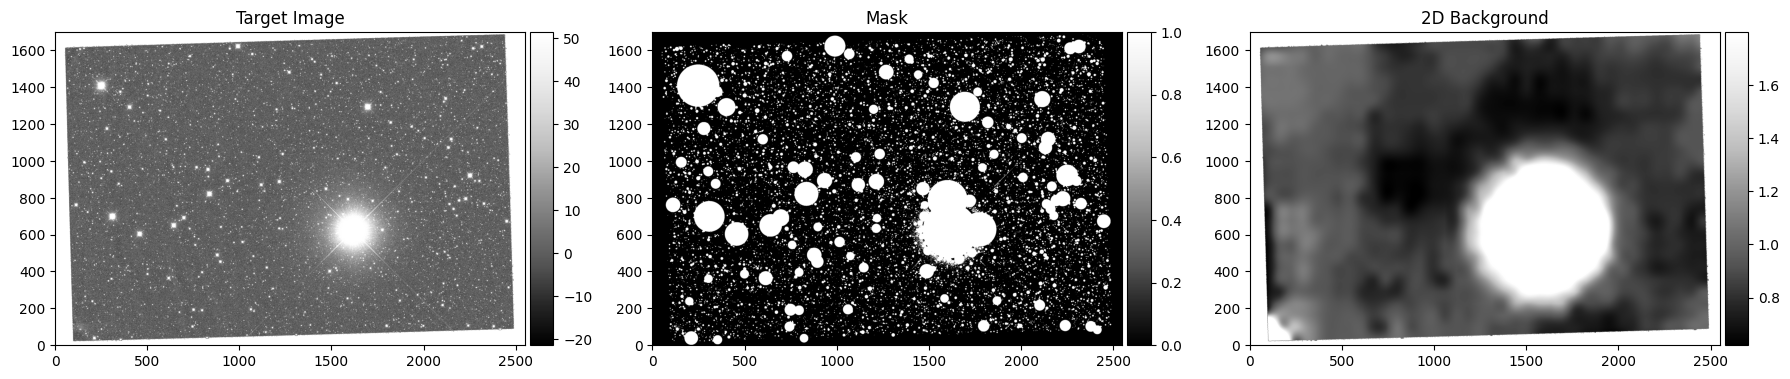

In [34]:
target_bkg = target_img.calculate_bkg(
    target_srcmask = target_srcmask,
    target_ivpmask = target_ivpmask,
    is_2D_bkg = True,
    box_size = 256,
    filter_size = 5,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False,
)